In [1]:
import warnings
warnings.simplefilter('ignore')
import sys
sys.path.append('../pybeh')
import cmlreaders as cml
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import pandas as pd
import pandas_to_pybeh as pb
import scipy as scp
import re
import math
import pickle
pd.options.display.max_rows = 100
pd.options.display.max_columns = 50

%matplotlib inline
import importlib
import statsmodels.api as sm
from statsmodels.stats.anova import AnovaRM

In [2]:
subjects = ['LTP564', 'LTP565', 'LTP566', 'LTP567', 'LTP568', 'LTP569', 'LTP571', 'LTP572', 'LTP573',
            'LTP574', 'LTP575', 'LTP576', 'LTP577', 'LTP578', 'LTP579', 'LTP580', 'LTP581', 'LTP583',
            'LTP584', 'LTP585', 'LTP586', 'LTP587', 'LTP588', 'LTP589', 'LTP590', 'LTP591', 'LTP592', 
            'LTP593', 'LTP594', 'LTP595', 'LTP596', 'LTP597', 'LTP598', 'LTP599', 'LTP600', 'LTP601', 
            'LTP602', 'LTP603', 'LTP604', 'LTP605']

In [3]:
# excluding subjects with only one preprocessed session 

# subjects = ['LTP564', 'LTP565', 'LTP566', 'LTP567', 'LTP568', 'LTP569', 'LTP571', 'LTP572', 'LTP573',
#             'LTP574', 'LTP575', 'LTP576', 'LTP577', 'LTP578', 'LTP580', 'LTP581', 'LTP583',
#             'LTP584', 'LTP585', 'LTP586', 'LTP587', 'LTP588', 'LTP589', 'LTP591', 'LTP592', 
#             'LTP594', 'LTP595', 'LTP596', 'LTP597', 'LTP598', 'LTP599', 'LTP601', 
#             'LTP602', 'LTP603', 'LTP604', 'LTP605']

In [4]:
experiment = 'CourierReinstate1'
data = cml.get_data_index(kind = 'ltp')
data = data[(data['experiment']==experiment)].sort_values('session').reset_index()

full_evs = None
for i, row in data.iterrows():
    # intialize data reader, load words events and buffered eeg epochs
    r = cml.CMLReader(subject=row['subject'], experiment=row['experiment'], session=row['session'])
    evs = r.load('task_events')
    full_evs = evs if full_evs is None else pd.concat([full_evs, evs], ignore_index=True)
full_evs = full_evs.query('subject in @subjects')

In [5]:
full_evs = full_evs[(full_evs['item'] != "AMPLIFIER") & (full_evs['item'] != "APPLE") & (full_evs['item'] != "AXE") & 
                    (full_evs['item'] != "BASKETBALL_HOOP") & (full_evs['item'] != "DOOR") & (full_evs['item'] != "IRONING_BOARD") & 
                    (full_evs['item'] != "SHOVEL") & (full_evs['item'] != "STOVE")]
full_evs

,eegoffset,classifier,correctPointingDirection,eegfile,efr_mark,eogArtifact,experiment,finalrecalled,intruded,intrusion,item,itemno,montage,msoffset,mstime,phase,presX,presZ,protocol,recalled,rectime,serialpos,session,store,storeX,storeZ,subject,submittedPointingDirection,trial,type
0,188099,X,-999,/protocols/ltp/subjects/LTP592/experiments/Cou...,-999,-1,CourierReinstate1,-999,-999,-999,-999,-999,0,-1,1752089748679,1,-999.000000,-999.000000,ltp,-999,-999,-999,0,-999,-999.00000,-999.00000,LTP592,-999,0,store mappings
1,202442,X,-999,/protocols/ltp/subjects/LTP592/experiments/Cou...,-999,-1,CourierReinstate1,-999,-999,-999,-999,-1,0,-1,1752089755684,1,-999.000000,-999.000000,ltp,-999,-999,-999,0,-999,-999.00000,-999.00000,LTP592,-999,0,VIDEO_START
2,605229,X,-999,/protocols/ltp/subjects/LTP592/experiments/Cou...,-999,-1,CourierReinstate1,-999,-999,-999,-999,-1,0,-1,1752089952398,1,-999.000000,-999.000000,ltp,-999,-999,-999,0,-999,-999.00000,-999.00000,LTP592,-999,0,VIDEO_STOP
3,820132,X,-999,/protocols/ltp/subjects/LTP592/experiments/Cou...,-999,-1,CourierReinstate1,-999,-999,-999,-999,-999,0,-1,1752090057353,1,-999.000000,-999.000000,ltp,-999,-999,-999,0,-999,-999.00000,-999.00000,LTP592,-999,0,TL_START
4,1548717,X,-999,/protocols/ltp/subjects/LTP592/experiments/Cou...,-999,-1,CourierReinstate1,-999,-999,-999,-999,-999,0,-1,1752090413181,1,46.406250,29.484375,ltp,-999,-999,-999,0,-999,-999.00000,-999.00000,LTP592,-999,0,TL_END
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
216727,7652143,X,-999,/protocols/ltp/subjects/LTP571/experiments/Cou...,-999,-1,CourierReinstate1,-999,-999,0,TABLE,35,0,20,1748468097506,1,-26.515625,-46.218750,ltp,-999,17054,4,6,cafe,59.28125,-9.15625,LTP571,-999,9,REC_WORD
216728,7703205,X,-999,/protocols/ltp/subjects/LTP571/experiments/Cou...,-999,-1,CourierReinstate1,-999,-999,0,COFFEE_MACHINE,81,0,20,1748468122440,1,-26.515625,-46.218750,ltp,-999,41988,2,6,bakery,-60.00000,-11.50000,LTP571,-999,9,REC_WORD
216729,7704628,X,-999,/protocols/ltp/subjects/LTP571/experiments/Cou...,-999,-1,CourierReinstate1,-999,-999,0,REFRIGERATOR,53,0,20,1748468123135,1,-26.515625,-46.218750,ltp,-999,42683,1,6,music_store,-31.81250,55.71875,LTP571,-999,9,REC_WORD
216730,7801530,X,-999,/protocols/ltp/subjects/LTP571/experiments/Cou...,-999,-1,CourierReinstate1,-999,-999,-999,-999,-999,0,-1,1748468170452,1,-26.515625,-46.218750,ltp,-999,-999,-999,6,-999,-999.00000,-999.00000,LTP571,-999,9,REC_STOP


In [6]:
with open("courier_wordpool_fixed.txt") as f:
    pool_raw = [w.strip() for w in f if w.strip()]
if pool_raw and pool_raw[0].lower() == "word":
    pool_raw = pool_raw[1:]

pool = [w.upper() for w in pool_raw]
pool_map = {w: i+1 for i, w in enumerate(pool)}

def norm(s):
    return (str(s).strip().upper().replace(" ", "_"))

full_evs["item_key"] = full_evs["item"].map(norm)
full_evs["itemno"]   = full_evs["item_key"].map(pool_map)

### Recall Statistics

In [7]:
pres = full_evs.type=='WORD'
recall_by_sub = full_evs[pres].groupby('subject')\
    .agg({'recalled':'mean'})\
    .rename(columns={"recalled":"Recall Probability"}
)
recall_by_sub = recall_by_sub.reset_index()
recall_by_sub = recall_by_sub.sort_values(by="Recall Probability", ascending=True)
sub_recall = recall_by_sub.subject.values
recall_by_sub

,subject,Recall Probability
30,LTP596,0.301387
5,LTP569,0.346056
4,LTP568,0.418251
31,LTP597,0.431818
33,LTP599,0.434358
39,LTP605,0.466328
3,LTP567,0.517483
14,LTP579,0.527778
10,LTP575,0.541667
38,LTP604,0.564005


In [8]:
print(f"Mean = {recall_by_sub['Recall Probability'].mean()}, SD = {recall_by_sub['Recall Probability'].std()}")

Mean = 0.7053905942677817, SD = 0.1766757942264987


### Serial Position Curve

In [9]:
spc_df = full_evs.query("type=='WORD'").groupby(
    ['subject', 'session', 'serialpos']
).agg({'recalled':np.nanmean}).reset_index()

avg_spc_df = spc_df.groupby(["subject","serialpos"]).agg({"recalled":"mean"}).reset_index()

In [10]:
avg_spc_df

,subject,serialpos,recalled
0,LTP564,1,0.708333
1,LTP564,2,0.781818
2,LTP564,3,0.750000
3,LTP564,4,0.598611
4,LTP564,5,0.762500
...,...,...,...
595,LTP605,11,0.377315
596,LTP605,12,0.372222
597,LTP605,13,0.469444
598,LTP605,14,0.537500


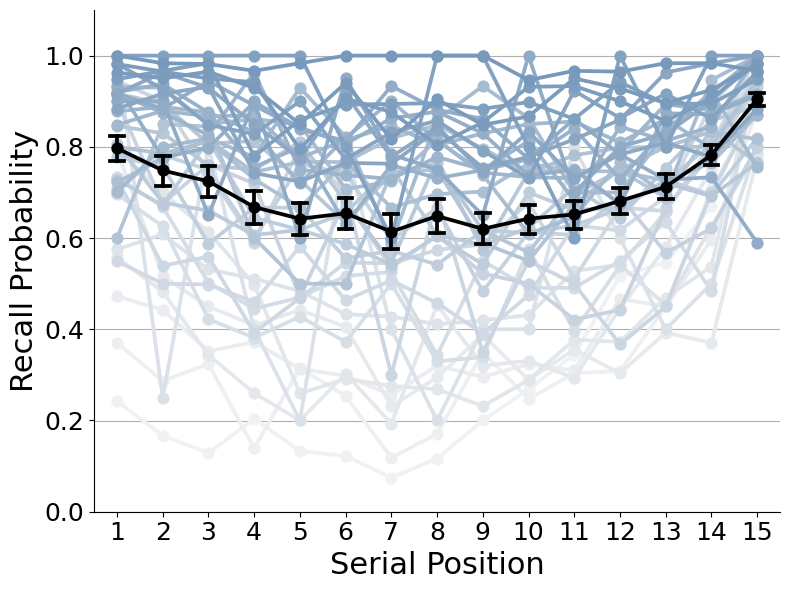

In [11]:
fig = plt.figure(figsize=(8, 6))
ax = plt.gca()

colors = sns.light_palette("#79B", len(sub_recall))
for i, sub in enumerate(sub_recall):
    sub_df = avg_spc_df.query('subject == @sub')
    sub_spc = sns.pointplot(data=sub_df, x='serialpos', y='recalled', ci=None, ax=ax, color=colors[i])
    
spc = sns.pointplot(data=avg_spc_df, x='serialpos', y='recalled', ci=68, capsize=.3, ax=ax, color="k")

plt.xlabel('Serial Position', fontsize=22)
plt.ylabel('Recall Probability', fontsize=22)
plt.tick_params(labelsize=18)
plt.ylim(0, 1.1)
spc.yaxis.grid()
plt.tight_layout()
ax.spines.top.set_visible(False)
ax.spines.right.set_visible(False)
plt.show()

In [12]:
early_spc = avg_spc_df.query('serialpos < 4').groupby('subject').agg({"recalled":"mean"}).reset_index()
middle_spc = avg_spc_df.query('4 <= serialpos <= 12').groupby('subject').agg({"recalled":"mean"}).reset_index()
late_spc = avg_spc_df.query('serialpos > 12').groupby('subject').agg({"recalled":"mean"}).reset_index()

# Primacy Effect
print("Primacy:", scp.stats.ttest_rel(early_spc["recalled"], middle_spc["recalled"]))

# Recency Effect
print("Recency:", scp.stats.ttest_rel(late_spc["recalled"], middle_spc["recalled"]))

Primacy: TtestResult(statistic=8.088759692120215, pvalue=7.208866604571923e-10, df=39)
Recency: TtestResult(statistic=6.759198366186041, pvalue=4.59578051216659e-08, df=39)


### Probability of First Recall

In [13]:
recword = full_evs.query('type=="REC_WORD"')
recword['pos'] = recword.groupby(['subject', 'session', 'trial']).cumcount()
first_recall_df = recword.query('pos == 0 and serialpos >= 0')
first_recall_df = first_recall_df.groupby(
    ['subject', 'serialpos']).agg(
    {'recalled': 'count'}).unstack(fill_value=0).stack().reset_index()
first_recall_df['n_lists'] = first_recall_df.groupby(['subject'])['recalled'].transform('sum')
first_recall_df['prob'] = first_recall_df['recalled'] / first_recall_df['n_lists']
first_recall_df

,subject,serialpos,recalled,n_lists,prob
0,LTP564,1,2,41,0.048780
1,LTP564,2,3,41,0.073171
2,LTP564,3,1,41,0.024390
3,LTP564,4,3,41,0.073171
4,LTP564,5,3,41,0.073171
...,...,...,...,...,...
595,LTP605,11,0,52,0.000000
596,LTP605,12,1,52,0.019231
597,LTP605,13,0,52,0.000000
598,LTP605,14,2,52,0.038462


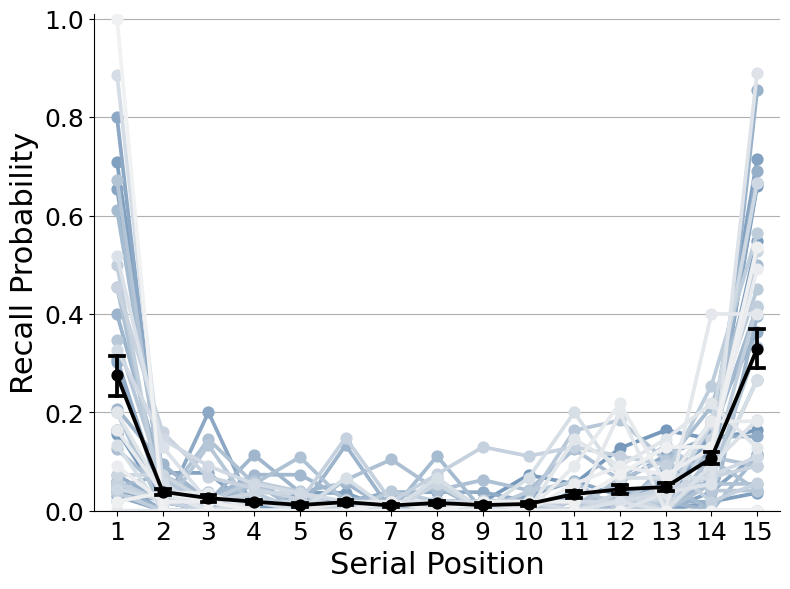

In [14]:
fig = plt.figure(figsize=(8, 6))
ax = plt.gca()

colors = sns.light_palette("#79B", len(sub_recall))
for i, sub in enumerate(sub_recall):
    sub_df = first_recall_df.query('subject == @sub')
    sub_spc = sns.pointplot(data=sub_df, x='serialpos', y='prob', ci=None, ax=ax, color=colors[len(colors)-i-1])

spc = sns.pointplot(data=first_recall_df, x='serialpos', y='prob', ci=68, capsize=.3, ax=ax, color="k")

plt.xlabel('Serial Position', fontsize=22)
plt.ylabel('Recall Probability', fontsize=22)
plt.tick_params(labelsize=18)
plt.ylim(0, 1.01)
plt.tight_layout()
ax.spines.top.set_visible(False)
ax.spines.right.set_visible(False)
spc.yaxis.grid()
plt.show()

In [15]:
early_pfr = first_recall_df.query('serialpos < 4').groupby('subject').agg({"prob":"mean"}).reset_index()
middle_pfr = first_recall_df.query('4 <= serialpos <= 12').groupby('subject').agg({"prob":"mean"}).reset_index()
late_pfr = first_recall_df.query('serialpos > 12').groupby('subject').agg({"prob":"mean"}).reset_index()

# Primacy Effect
print("Primacy:", scp.stats.ttest_rel(early_pfr["prob"], middle_pfr["prob"]))

# Recency Effect
print("Recency:", scp.stats.ttest_rel(late_pfr["prob"], middle_pfr["prob"]))

Primacy: TtestResult(statistic=5.486506773349551, pvalue=2.672847306849609e-06, df=39)
Recency: TtestResult(statistic=8.337214556184255, pvalue=3.378627614198462e-10, df=39)


### Temporal CRP

In [16]:
rec_word_types_all = ['REC_WORD', 'REC_WORD_VV']
present_types = set(full_evs['type'].unique())
present_rec_types = [t for t in rec_word_types_all if t in present_types]

need_types = ['WORD'] + present_rec_types
clean_evs = full_evs[full_evs['type'].isin(need_types)].copy()

print("Kept rows:", len(clean_evs))
print("Kept types:", sorted(clean_evs['type'].unique()))

for t in present_rec_types:
    if t != 'REC_WORD':
        clean_evs.loc[clean_evs['type'] == t, 'type'] = 'REC_WORD'

print("Types after normalization:", sorted(clean_evs['type'].unique()))

is_word = clean_evs['type'].eq('WORD')
is_rec  = clean_evs['type'].eq('REC_WORD')

dropped_word = (is_word & clean_evs['itemno'].isna()).sum()
temporal_evs = clean_evs[~(is_word & clean_evs['itemno'].isna())].copy()
filled_rec = temporal_evs.loc[is_rec, 'itemno'].isna().sum()
temporal_evs.loc[is_rec, 'itemno'] = temporal_evs.loc[is_rec, 'itemno'].fillna(0)

print(f"Dropped WORD rows with NaN itemno: {dropped_word}")
print(f"Filled NaN in REC_WORD rows: {filled_rec}")
print("NaNs remaining in temporal_evs.itemno:", temporal_evs['itemno'].isna().sum())

temporal_evs['itemno'] = temporal_evs['itemno'].astype('int64')
temporal_evs

Kept rows: 49540
Kept types: ['REC_WORD', 'REC_WORD_VV', 'WORD']
Types after normalization: ['REC_WORD', 'WORD']
Dropped WORD rows with NaN itemno: 86
Filled NaN in REC_WORD rows: 1750
NaNs remaining in temporal_evs.itemno: 0


,eegoffset,classifier,correctPointingDirection,eegfile,efr_mark,eogArtifact,experiment,finalrecalled,intruded,intrusion,item,itemno,montage,msoffset,mstime,phase,presX,presZ,protocol,recalled,rectime,serialpos,session,store,storeX,storeZ,subject,submittedPointingDirection,trial,type,item_key
17,3901393,X,-999,/protocols/ltp/subjects/LTP592/experiments/Cou...,-999,0,CourierReinstate1,0,0,-999,DISH_SOAP,111,0,-1,1752091562187,1,48.593750,-11.093750,ltp,1,-999,1,0,craft_shop,59.281250,-9.156250,LTP592,-999,0,WORD,DISH_SOAP
18,3927737,X,-999,/protocols/ltp/subjects/LTP592/experiments/Cou...,-999,3,CourierReinstate1,0,0,-999,CEREAL,100,0,-1,1752091575053,1,-8.515625,1.511719,ltp,0,-999,2,0,barber_shop,-9.093750,17.859375,LTP592,-999,0,WORD,CEREAL
19,3959749,X,-999,/protocols/ltp/subjects/LTP592/experiments/Cou...,-999,0,CourierReinstate1,0,0,-999,SLIDE,47,0,-1,1752091590687,1,0.549316,-8.335938,ltp,0,-999,3,0,bakery,-14.250000,-12.890625,LTP592,-999,0,WORD,SLIDE
21,4054891,X,-999,/protocols/ltp/subjects/LTP592/experiments/Cou...,-999,3,CourierReinstate1,0,0,-999,WATERMELON,99,0,-1,1752091637153,1,-48.062500,-8.468750,ltp,1,-999,4,0,gym,-60.000000,-11.500000,LTP592,-999,0,WORD,WATERMELON
22,4076256,X,-999,/protocols/ltp/subjects/LTP592/experiments/Cou...,-999,1,CourierReinstate1,0,0,-999,SODA,16,0,-1,1752091647587,1,-9.781250,-49.875000,ltp,0,-999,5,0,grocery_store,-3.070312,-58.500000,LTP592,-999,0,WORD,SODA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
216725,7644160,X,-999,/protocols/ltp/subjects/LTP571/experiments/Cou...,-999,-1,CourierReinstate1,-999,-999,-1,<>,0,0,20,1748468093608,1,-26.515625,-46.218750,ltp,-999,13156,-999,6,-999,-999.000000,-999.000000,LTP571,-999,9,REC_WORD,<>
216726,7649536,X,-999,/protocols/ltp/subjects/LTP571/experiments/Cou...,-999,-1,CourierReinstate1,-999,-999,0,POOL_TABLE,42,0,20,1748468096233,1,-26.515625,-46.218750,ltp,-999,15781,3,6,pet_store,-14.250000,-12.890625,LTP571,-999,9,REC_WORD,POOL_TABLE
216727,7652143,X,-999,/protocols/ltp/subjects/LTP571/experiments/Cou...,-999,-1,CourierReinstate1,-999,-999,0,TABLE,34,0,20,1748468097506,1,-26.515625,-46.218750,ltp,-999,17054,4,6,cafe,59.281250,-9.156250,LTP571,-999,9,REC_WORD,TABLE
216728,7703205,X,-999,/protocols/ltp/subjects/LTP571/experiments/Cou...,-999,-1,CourierReinstate1,-999,-999,0,COFFEE_MACHINE,80,0,20,1748468122440,1,-26.515625,-46.218750,ltp,-999,41988,2,6,bakery,-60.000000,-11.500000,LTP571,-999,9,REC_WORD,COFFEE_MACHINE


In [17]:
temporal_clustering_df = temporal_evs.groupby(['subject']).apply(
    pb.pd_temp_fact,
    itemno_column='itemno',
    list_index=['subject', 'session', 'trial'],
    skip_first_n=0).rename('TC').reset_index()
temporal_clustering_df.sort_values(by='TC', ascending=True)

,subject,TC
8,LTP573,0.547070
28,LTP594,0.558515
39,LTP605,0.569779
11,LTP576,0.596628
31,LTP597,0.609055
37,LTP603,0.610644
33,LTP599,0.617075
7,LTP572,0.621724
0,LTP564,0.623974
12,LTP577,0.631427


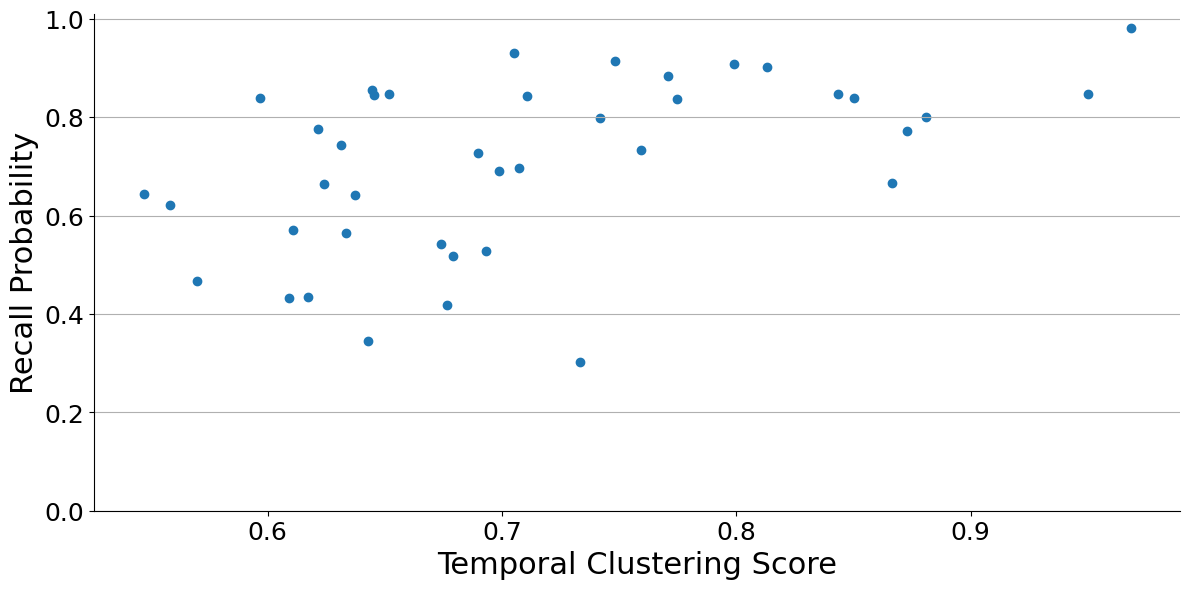

[[1.       0.495542]
 [0.495542 1.      ]]


In [18]:
temp_clustering_recall_prob = pd.merge(temporal_clustering_df, recall_by_sub, on='subject')

fig = plt.figure(figsize=(12, 6))
fig.patch.set_facecolor('white')
ax = plt.gca()

tc_vs_recall = plt.scatter(temp_clustering_recall_prob['TC'], temp_clustering_recall_prob['Recall Probability'])

ax.set_xlabel('Temporal Clustering Score', fontsize=22)
ax.set_ylabel('Recall Probability', fontsize=22)
ax.tick_params(labelsize=18)
plt.ylim([0,1.01])
ax.yaxis.grid()
ax.spines.right.set_visible(False)
ax.spines.top.set_visible(False)

plt.tight_layout()
plt.show()

print(np.corrcoef(temp_clustering_recall_prob['TC'], temp_clustering_recall_prob['Recall Probability']))

In [19]:
crp_df = temporal_evs.groupby(['subject']).apply(
    pb.pd_crp,
    itemno_column='itemno',
    list_index=['subject', 'session', 'trial'],
    lag_num=14).reset_index()

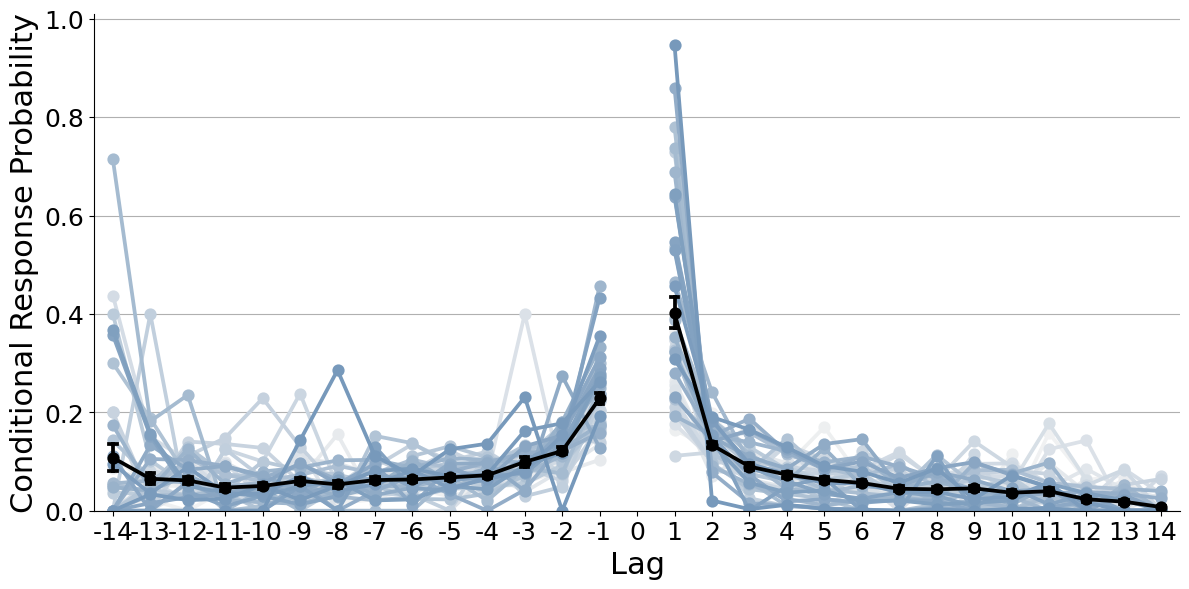

In [20]:
fig = plt.figure(figsize=(12, 6))
fig.patch.set_facecolor('white')
ax = plt.gca()

from matplotlib.colors import ListedColormap

colors = sns.light_palette("#79B", len(sub_recall))
for i, sub in enumerate(sub_recall):
    sub_crp = crp_df.query('subject == @sub')
    sns.pointplot(data=sub_crp, x="lag", y="prob", 
                  color= colors[i], 
                  ax=ax,
                  linestyles="-")

crp = sns.pointplot(data=crp_df, x='lag', y='prob', ci=68,
                    color='k', capsize=.2, ax=ax)

ax.set_xlabel('Lag', fontsize=22)
ax.set_ylabel('Conditional Response Probability', fontsize=22)
ax.tick_params(labelsize=18)
plt.ylim([0,1.01])
ax.yaxis.grid()
ax.spines.right.set_visible(False)
ax.spines.top.set_visible(False)

plt.tight_layout()
plt.show()

### Spatial CRP

In [21]:
spatial_evs = temporal_evs.copy()
is_word_s = spatial_evs['type'].eq('WORD')
is_rec_s  = spatial_evs['type'].eq('REC_WORD')

spatial_evs = spatial_evs[~(is_word_s & (spatial_evs['itemno'].isna() | spatial_evs['storeX'].isna() | spatial_evs['storeZ'].isna()))].copy()
spatial_evs.loc[is_rec_s, 'itemno'] = spatial_evs.loc[is_rec_s, 'itemno'].fillna(-1)
spatial_evs['itemno'] = spatial_evs['itemno'].astype('int64')

def apply_dense_dist_fact(g):
    # Build a dense 1..K mapping from the WORD ids actually present in this subject slice
    word_ids = g.loc[g['type']=='WORD', 'itemno'].dropna().astype(int).unique()
    word_ids.sort()
    id_map = {old: i+1 for i, old in enumerate(word_ids)}  # dense 1..K

    g2 = g.copy()
    g2['itemno_dense'] = g2['itemno'].map(id_map)  # WORDs map to 1..K; RECs map if seen
    # RECs not seen among WORDs → sentinel -1
    rec_mask = g2['type'].eq('REC_WORD')
    g2.loc[rec_mask, 'itemno_dense'] = g2.loc[rec_mask, 'itemno_dense'].fillna(-1)

    # Drop any WORD rows that somehow failed to map (shouldn’t happen, but safe)
    g2 = g2[~(g2['type'].eq('WORD') & g2['itemno_dense'].isna())].copy()
    g2['itemno_dense'] = g2['itemno_dense'].astype('int64')

    return pb.pd_dist_fact(
        g2,
        itemno_column='itemno_dense',
        list_index=['subject','session','trial'],
        sim_columns=['storeX','storeZ'],
        word_val_type='WORD',
        skip_first_n=0
    )

spatial_clustering_df = (
    spatial_evs.groupby('subject', sort=False)
               .apply(apply_dense_dist_fact)
               .rename('SC')
               .reset_index()
)

spatial_clustering_df.sort_values(by='SC', ascending=True)

,subject,SC
3,LTP572,0.462468
35,LTP590,0.469266
37,LTP567,0.471918
27,LTP598,0.473651
34,LTP599,0.473830
2,LTP593,0.474601
39,LTP566,0.476840
28,LTP597,0.478157
38,LTP565,0.480076
8,LTP587,0.481011


In [22]:
subject_clustering_df = pd.merge(temporal_clustering_df, spatial_clustering_df, on='subject')
subject_clustering_df

,subject,TC,SC
0,LTP564,0.623974,0.493808
1,LTP565,0.880953,0.480076
2,LTP566,0.866348,0.476840
3,LTP567,0.679142,0.471918
4,LTP568,0.676598,0.489390
5,LTP569,0.642701,0.512675
6,LTP571,0.950041,0.538799
7,LTP572,0.621724,0.462468
8,LTP573,0.547070,0.526255
9,LTP574,0.705060,0.501613


In [23]:
def compute_distance(coord1, coord2):
    z1, x1 = coord1
    z2, x2 = coord2
    return math.sqrt((z2 - z1)**2 + (x2 - x1)**2)

In [27]:
spatial_CRPs = [[]]*len(subjects)
x_mids_by_sub = [[]]*len(subjects)
tot_act_by_sub = [[]]*len(subjects)
tot_pos_by_sub = [[]]*len(subjects)

for t, sub in enumerate(subjects):
    total_actual  = np.zeros(5, dtype=float)
    total_possible = np.zeros(5, dtype=float)
    mid_weighted_sum = np.zeros(5, dtype=float)
    
    sub_data = data[data.subject == sub]
    sub_CRP = []
    for sess in np.unique(sub_data.session):
        
        reader = cml.CMLReader(subject=sub,
                           session=sess,
                           experiment='CourierReinstate1')
        evs = reader.load('task_events')
        rec_evs = evs[evs.type == 'REC_WORD']
        word_evs = evs[evs.type == 'WORD']
        if len(word_evs) > 150:
            continue
        pres_words = np.array(word_evs.item)
        
        # Get coordinates of locations where items presented
        pres_loc = []
        for i in range(len(word_evs)):
            pres_loc.append([np.array(word_evs.presX)[i], np.array(word_evs.presZ)[i]])
        pres_loc = np.array(pres_loc)

        # Compute Euclidean distances between all item locations
        item_dists = []
        for i in range(min(len(pres_loc), 150)):
            temp_dists = []
            for j in range(min(len(pres_loc), 150)):
                temp_dists.append(compute_distance(pres_loc[i], pres_loc[j]))
            item_dists.append(temp_dists)
        item_dists = np.array(item_dists)

        flat = item_dists[np.triu_indices_from(item_dists, k=1)]
        if flat.size == 0:
            continue
        edges = np.quantile(flat, [0, .2, .4, .6, .8, 1.0])
        for i in range(1, len(edges)):
            if edges[i] <= edges[i-1]:
                edges[i] = np.nextafter(edges[i-1], np.inf)
        cutpoints = edges[1:-1] 
        mids = (edges[:-1] + edges[1:]) / 2
        
        actual_transitions = []
        possible_transitions = []
        for list in np.unique(rec_evs.trial):
            list_recs = rec_evs[rec_evs.trial == list]
            list_enc = word_evs[word_evs.trial == list]
            list_pres_words = np.array(list_enc.item)
            serpos = np.array(range(0,15))
            list_dist = []
            
            # Skip if delivery day incomplete
            if len(list_enc) < 15:
                continue
                
            # Iterate over recalls for current delivery day
            for recs in range(1, len(list_recs)):
                rec_word = np.array(list_recs.item)[recs - 1]
                next_rec = np.array(list_recs.item)[recs]
                # Skip intrusions
                if np.in1d(rec_word, np.array(list_enc.item)) == False:
                    continue
                if np.in1d(next_rec, np.array(list_enc.item)) == False:
                    continue
                # Skip repeats
                if np.in1d(rec_word, np.array(list_recs.item)[:recs-1]):
                    continue
                if np.in1d(next_rec, np.array(list_recs.item)[:recs-1]):
                    continue       

                # Get spatial distance bins between current recall and all other words
                temp_dists = []
                for i in range(len(list_enc.item)):
                    curr_word = np.array(list_enc.item)[i]
                    dist = item_dists[np.where(pres_words == rec_word)[0][0]][np.where(pres_words == curr_word)[0][0]]
                    temp_dists.append(dist)
                    
                temp_dists = np.array(temp_dists)
                temp_inds = np.digitize(temp_dists, cutpoints) + 1
                
                actual_transitions = np.append(actual_transitions, temp_inds[np.array(list_recs.serialpos)[recs] - 1]) # Distance bin of actual transition
                not_yet_rec = np.in1d(serpos, np.array(list_recs.serialpos)[:recs] - 1) == False
                possible_transitions = np.append(possible_transitions, temp_inds[(not_yet_rec == True) & (np.array(temp_dists) > 0)])
                
        sess_actual   = np.array([np.sum(actual_transitions   == b) for b in range(1, 6)], dtype=float)
        sess_possible = np.array([np.sum(possible_transitions == b) for b in range(1, 6)], dtype=float)
        total_actual  += sess_actual
        total_possible += sess_possible
        mid_weighted_sum += mids * sess_possible


        actual_sum = []
        possible_sum = []
        for i in range(1,6):
            actual_sum.append(sum(actual_transitions == i))
            possible_sum.append(sum(possible_transitions == i))

        CRP = np.array(actual_sum)/np.array(possible_sum)
        sub_CRP.append(CRP)
        
        for b in range(1, 6):
            total_actual[b-1]  += np.sum(actual_transitions == b)
            total_possible[b-1] += np.sum(possible_transitions == b)

    spatial_CRPs[t] = np.divide(total_actual, total_possible, out=np.full(5, np.nan), where=total_possible > 0)
    x_mids_by_sub[t] = np.divide(mid_weighted_sum, total_possible, out=np.full(5, np.nan), where=total_possible > 0)
    tot_act_by_sub[t] = total_actual
    tot_pos_by_sub[t] = total_possible

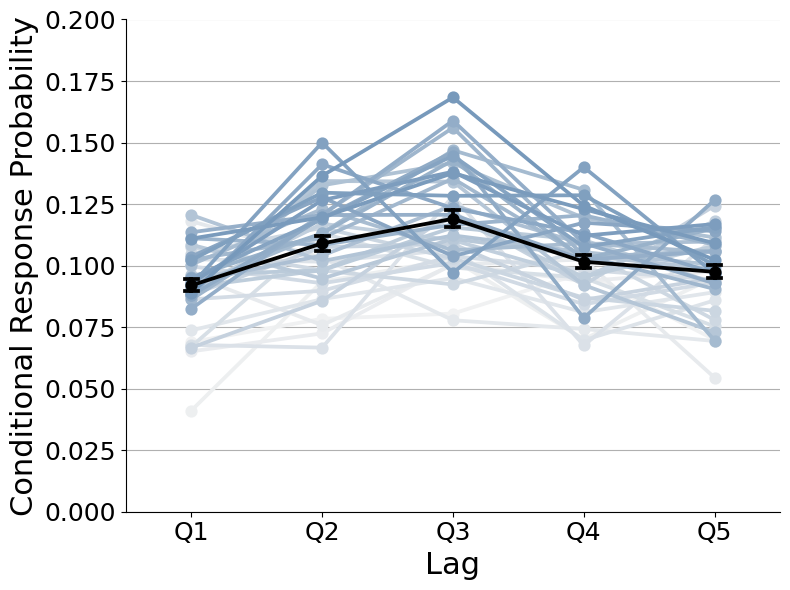

In [28]:
rows = []
for sub, crp in zip(subjects, spatial_CRPs):
    if crp is None or np.all(np.isnan(crp)): 
        continue
    for b, y in enumerate(crp, start=1):
        rows.append({"subject": sub, "bin": b, "bin_label": f"Q{b}", "crp": y})
df_long = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(8, 6))

colors = sns.light_palette("#79B", df_long['subject'].nunique())
order = ["Q1","Q2","Q3","Q4","Q5"]
for i, sub in enumerate(sub_recall):
    sub_df = df_long[df_long["subject"] == sub]
    if sub_df.empty: 
        continue
    sns.pointplot(data=sub_df, x="bin_label", y="crp", 
                  order=order, color=colors[i], 
                  ax=ax, linestyles="-")

sns.pointplot(data=df_long, x="bin_label", y="crp", order=order, color="black", capsize=.1, ci=68, ax=ax)

ax.set_xlabel("Lag", fontsize=22)
ax.set_ylabel("Conditional Response Probability", fontsize=22)
ax.yaxis.grid()
# plt.ylim([0, 0.75])  # same scale as Dougherty
plt.ylim([0, 0.2])
ax.tick_params(labelsize=18)
ax.spines.top.set_visible(False)
ax.spines.right.set_visible(False)

plt.tight_layout()
plt.show()